# 04 - Time Series Modeling

This notebook builds forecasting baselines with ARIMA/SARIMAX-style models.
Primary objective: establish interpretable time-series benchmarks with time-aware evaluation.


## Modeling Scope
1. Aggregate daily sales series for chain-level trend modeling.
2. Fit SARIMAX with exogenous calendar/promo signals.
3. Evaluate on chronological holdout using RMSE and RMSPE.
4. Provide store-level example forecast workflow.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


In [ ]:
# Compatibility patch for older pandas versions where DatetimeIndex lacks quantile.
if not hasattr(pd.DatetimeIndex, "quantile"):
    def _dtindex_quantile(self, q=0.5, interpolation="linear"):
        return pd.Series(self).quantile(q=q, interpolation=interpolation)
    pd.DatetimeIndex.quantile = _dtindex_quantile

print("DatetimeIndex.quantile available:", hasattr(pd.DatetimeIndex, 'quantile'))


In [2]:
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(RAW_DIR / "train.csv", parse_dates=["Date"])

# Restrict to open days with positive sales to avoid closed-day zeros dominating signal.
df = train[(train["Open"] == 1) & (train["Sales"] > 0)].copy()
print(df.shape)


(844338, 9)


## Build Daily Aggregated Series and Exogenous Regressors


In [3]:
daily = (
    df.groupby("Date", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        PromoRate=("Promo", "mean"),
        SchoolHolidayRate=("SchoolHoliday", "mean"),
        AvgCustomers=("Customers", "mean"),
    )
    .sort_values("Date")
)

daily["DayOfWeek"] = daily["Date"].dt.dayofweek
daily["Month"] = daily["Date"].dt.month

daily = daily.set_index("Date")
daily.head()


,Sales,PromoRate,SchoolHolidayRate,AvgCustomers,DayOfWeek,Month
Date,,,,,,
2013-01-01,97235,0.0,1.000000,1146.529412,1,1
2013-01-02,6949829,0.0,1.000000,750.742574,2,1
2013-01-03,6347820,0.0,0.932372,686.239856,3,1
2013-01-04,6638954,0.0,0.932310,705.899819,4,1
2013-01-05,5951593,0.0,0.100271,621.022584,5,1


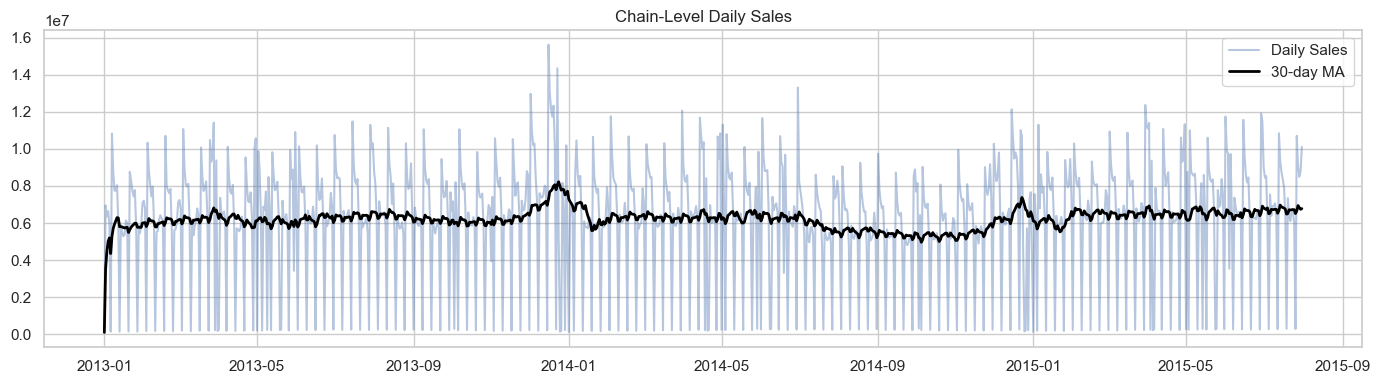

In [4]:
# Visualize time series and moving average.
daily["Sales_MA30"] = daily["Sales"].rolling(30, min_periods=1).mean()

plt.figure(figsize=(14, 4))
plt.plot(daily.index, daily["Sales"], alpha=0.4, label="Daily Sales")
plt.plot(daily.index, daily["Sales_MA30"], linewidth=2, color="black", label="30-day MA")
plt.title("Chain-Level Daily Sales")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ts_daily_sales_series.png", dpi=140)
plt.show()


## Stationarity Check (ADF)
- We test original and differenced series.
- ADF helps decide differencing order in ARIMA family models.


In [5]:
def adf_report(series, label):
    stat, p, _, _, _, _ = adfuller(series.dropna())
    print(f"{label} -> ADF stat={stat:.4f}, p-value={p:.6g}")

adf_report(daily["Sales"], "Sales")
adf_report(daily["Sales"].diff(), "Sales diff(1)")


Sales -> ADF stat=-4.7616, p-value=6.43673e-05
Sales diff(1) -> ADF stat=-14.0085, p-value=3.75004e-26


## Chronological Train/Validation Split


In [6]:
def rmspe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask])))

def chrono_split(df, frac=0.85):
    # Version-safe chronological split; avoids DatetimeIndex.quantile dependency.
    n = len(df)
    split_idx = int(n * frac)
    split_idx = max(1, min(split_idx, n - 1))
    train_part = df.iloc[:split_idx].copy()
    valid_part = df.iloc[split_idx:].copy()
    split_dt = train_part.index.max()
    return split_dt, train_part, valid_part

split_date, train_ts, valid_ts = chrono_split(daily, frac=0.85)

exog_cols = ["PromoRate", "SchoolHolidayRate", "AvgCustomers"]
for c in exog_cols:
    train_ts[c] = train_ts[c].fillna(0)
    valid_ts[c] = valid_ts[c].fillna(0)

print("split_date:", split_date)
print("train:", train_ts.shape, "valid:", valid_ts.shape)


AttributeError: 'DatetimeIndex' object has no attribute 'quantile'

## SARIMAX Baseline

Configuration `(1,1,1)x(1,1,1,7)` is a practical weekly-seasonality baseline.
Tune this grid later with walk-forward CV.


In [ ]:
# Weekly seasonal config when data is long enough; otherwise non-seasonal fallback.
seasonal_order = (1, 1, 1, 7) if len(train_ts) >= 120 else (0, 0, 0, 0)

model = SARIMAX(
    train_ts["Sales"],
    exog=train_ts[exog_cols],
    order=(1, 1, 1),
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

res = model.fit(disp=False)
print("seasonal_order used:", seasonal_order)
print(res.summary())


In [ ]:
pred = res.get_forecast(steps=len(valid_ts), exog=valid_ts[exog_cols])
valid_ts["Forecast"] = pred.predicted_mean

rmse = np.sqrt(np.mean((valid_ts["Sales"] - valid_ts["Forecast"]) ** 2))
r = rmspe(valid_ts["Sales"], valid_ts["Forecast"])

print("Validation RMSE :", round(rmse, 2))
print("Validation RMSPE:", round(r, 4))


In [ ]:
# Forecast visualization on validation horizon.
plt.figure(figsize=(14, 4))
plt.plot(train_ts.index, train_ts["Sales"], label="Train", alpha=0.5)
plt.plot(valid_ts.index, valid_ts["Sales"], label="Actual (Valid)", linewidth=2)
plt.plot(valid_ts.index, valid_ts["Forecast"], label="SARIMAX Forecast", linewidth=2)
plt.title("SARIMAX: Validation Forecast")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ts_sarimax_validation_forecast.png", dpi=140)
plt.show()


## Store-Level Example (Top Store by Sales)

Chain-level forecast is useful for aggregate planning.
Store-level models may improve operational decisions (staffing/inventory by location).


In [ ]:
store_sales = df.groupby("Store", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False)
top_store = int(store_sales.iloc[0]["Store"])
store_df = df[df["Store"] == top_store].copy()

store_daily = (
    store_df.groupby("Date", as_index=False)
    .agg(Sales=("Sales", "sum"), Promo=("Promo", "mean"), SchoolHoliday=("SchoolHoliday", "mean"))
    .sort_values("Date")
    .set_index("Date")
)

split_store, tr, va = chrono_split(store_daily, frac=0.85)
tr[["Promo", "SchoolHoliday"]] = tr[["Promo", "SchoolHoliday"]].fillna(0)
va[["Promo", "SchoolHoliday"]] = va[["Promo", "SchoolHoliday"]].fillna(0)

s_order_store = (1, 1, 0, 7) if len(tr) >= 120 else (0, 0, 0, 0)
m_store = SARIMAX(
    tr["Sales"],
    exog=tr[["Promo", "SchoolHoliday"]],
    order=(1, 1, 1),
    seasonal_order=s_order_store,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

va["Forecast"] = m_store.get_forecast(steps=len(va), exog=va[["Promo", "SchoolHoliday"]]).predicted_mean

print("Top store:", top_store)
print("Store split_date:", split_store)
print("Store seasonal_order used:", s_order_store)
print("Store-level RMSE:", round(np.sqrt(np.mean((va["Sales"] - va["Forecast"]) ** 2)), 2))


## Save Forecast Outputs


In [ ]:
out = valid_ts.reset_index()[["Date", "Sales", "Forecast"]]
out.to_csv(PROCESSED_DIR / "sarimax_daily_validation_forecast.csv", index=False)
print("Saved:", PROCESSED_DIR / "sarimax_daily_validation_forecast.csv")


## Next Steps
- Run parameter search (p,d,q)x(P,D,Q,s) with rolling CV.
- Compare SARIMAX against tree-based models using engineered lag features.
